# LAB 2


## LIBRARIES

In [40]:
import numpy as np
from enum import Enum
from collections import deque
import matplotlib.pyplot as plt

## CLASSES

### TASKCLASS

In [41]:


class TaskClass(Enum):
    """Enum to distinguish between delay-sensitive and delay-tolerant task classes"""
    DELAY_SENSITIVE = "delay_sensitive"      # Ks - low latency requirement
    DELAY_TOLERANT = "delay_tolerant"        # Kt - high latency tolerance


### TASK

In [42]:
class Task:
    """
    Represents a computational task generated by a sensing node.

    NEW MODEL (node-centric):
    - Each sensing node is either DELAY_SENSITIVE (Ks) or DELAY_TOLERANT (Kt).
    - All tasks generated by that node inherit the node class.
    - Task parameters (L, C, Dmax) are sampled from class-specific distributions.

    Parameters
    ----------
    task_class : TaskClass | str
        Fixed class of the task. Expected: TaskClass.DELAY_SENSITIVE or TaskClass.DELAY_TOLERANT.
        You can also pass strings: 'delay_sensitive'/'sensitive'/'ks', 'delay_tolerant'/'tolerant'/'kt'.
    custom_means : dict, optional
        Overrides class defaults. Keys: mean_L, mean_C, mean_Dmax.
    random_seed : int, optional
        Seed for reproducibility (sets NumPy global RNG seed for this task).
    """

    # Task class parameter configurations (means of exponential distributions)
    TASK_PARAMS = {
        TaskClass.DELAY_SENSITIVE: {
            "mean_L": 1e4,      # 10 kbits - smaller payloads
            "mean_C": 1e6,      # 1M cycles - moderate computation
            "mean_Dmax": 0.5,   # seconds - stricter deadlines
        },
        TaskClass.DELAY_TOLERANT: {
            "mean_L": 1e5,      # 100 kbits - larger payloads
            "mean_C": 1e7,      # 10M cycles - heavier computation
            "mean_Dmax": 2.0,   # seconds - looser deadlines
        },
    }

    @staticmethod
    def _parse_task_class(value):
        if isinstance(value, TaskClass):
            return value
        if isinstance(value, str):
            v = value.strip().lower()
            if v in {"delay_sensitive", "sensitive", "ks"}:
                return TaskClass.DELAY_SENSITIVE
            if v in {"delay_tolerant", "tolerant", "kt"}:
                return TaskClass.DELAY_TOLERANT
        raise ValueError("task_class must be a TaskClass or a supported string")

    def __init__(self, task_class, custom_means=None, random_seed=None):
        if random_seed is not None:
            np.random.seed(int(random_seed))

        self.task_class = self._parse_task_class(task_class)

        params = self.TASK_PARAMS[self.task_class].copy()
        if custom_means is not None:
            # allow partial overrides
            params.update(custom_means)

        mean_L = float(params["mean_L"])
        mean_C = float(params["mean_C"])
        mean_Dmax = float(params["mean_Dmax"])

        if mean_L <= 0 or mean_C <= 0 or mean_Dmax <= 0:
            raise ValueError("mean_L, mean_C and mean_Dmax must be > 0")

        # Sample parameters from exponential distributions (scale = mean)
        self.L = float(np.random.exponential(mean_L))        # Input data size [bits]
        self.C = float(np.random.exponential(mean_C))        # Computational demand [CPU cycles]
        self.Dmax = float(np.random.exponential(mean_Dmax))  # Latency constraint [seconds]

    def __repr__(self):
        return (f"Task(class={self.task_class.value}, "
                f"L={self.L:.2e} bits, "
                f"C={self.C:.2e} cycles, "
                f"Dmax={self.Dmax:.4f} s)")

    def __str__(self):
        return (f"\n{'='*60}\n"
                f"Task Details:\n"
                f"  Task Class: {self.task_class.value}\n"
                f"  Input Data Size (L): {self.L:.2e} bits\n"
                f"  Computational Demand (C): {self.C:.2e} CPU cycles\n"
                f"  Latency Constraint (Dmax): {self.Dmax:.4f} seconds\n"
                f"{'='*60}")

    def to_dict(self):
        return {
            "task_class": self.task_class.value,
            "L_bits": self.L,
            "C_cycles": self.C,
            "Dmax_seconds": self.Dmax,
        }

### QUEUE

In [43]:


class Queue:
    """
    Represents a processing queue in the HAPS-edge computing system.
    
    The queue manages Task objects with a given arrival rate and computational capacity.
    Each task in the queue has a service time calculated as C/fs, where:
    - C: computational demand of the task [CPU cycles]
    - fs: computational capacity of the queue [CPU cycles/second]
    
    Attributes
    ----------
    lambda_arrival : float
        Task arrival rate [tasks/second] - average number of tasks arriving per unit time
    fs : float
        Computational capacity of the queue [CPU cycles/second]
        Represents the processing speed of the server(s) in the queue
    tasks : deque
        FIFO buffer storing Task objects waiting for or being processed
    """
    
    def __init__(self, lambda_arrival, fs, max_buffer_size=None):
        """
        Initialize a Queue instance.
        
        Parameters
        ----------
        lambda_arrival : float
            Task arrival rate in [tasks/second]. Must be positive.
        fs : float
            Computational capacity of the queue in [CPU cycles/second]. Must be positive.
        max_buffer_size : int, optional
            Maximum number of tasks the queue can hold. If None, queue is unlimited.
            Default: None (unlimited)
        
        Returns
        -------
        None
        """
        
        # Validate input parameters
        if lambda_arrival <= 0:
            raise ValueError(f"lambda_arrival must be positive, got {lambda_arrival}")
        if fs <= 0:
            raise ValueError(f"fs must be positive, got {fs}")
        if max_buffer_size is not None and max_buffer_size <= 0:
            raise ValueError(f"max_buffer_size must be positive, got {max_buffer_size}")
        
        self.lambda_arrival = lambda_arrival           # Arrival rate [tasks/sec]
        self.fs = fs                                   # Computational capacity [cycles/sec]
        self.max_buffer_size = max_buffer_size         # Maximum buffer capacity
        self.tasks = deque()                           # FIFO buffer for tasks
    
    def get_service_rate(self, task):
            return task.C / self.fs
    
    def enqueue(self, task):
        """
        Add a task to the queue buffer.

        """
        
        if not isinstance(task, Task):
            raise TypeError(f"Expected Task instance, got {type(task)}")
        
        # Check if buffer is full (if max_buffer_size is set)
        if self.max_buffer_size is not None and len(self.tasks) >= self.max_buffer_size:
            return False  # Enqueue failed - buffer full
        
        self.tasks.append(task)
        return True  # Enqueue successful
    
    def dequeue(self):
        """
        Remove and return the first task from the queue (FIFO).
        
        """
        if len(self.tasks) == 0:
            return None
        return self.tasks.popleft()
    
    def peek(self):
        """
        View the first task without removing it (peek operation).
        
        """
        if len(self.tasks) == 0:
            return None
        return self.tasks[0]
    
    def is_empty(self):
        """
        Check if the queue is empty.
        
        """
        return len(self.tasks) == 0
    
    def is_full(self):
        """
        Check if the queue buffer is full.
        
        """
        if self.max_buffer_size is None:
            return False
        return len(self.tasks) >= self.max_buffer_size
    
    def get_queue_length(self):
        """
        Get the current number of tasks in the queue.
        
        """
        return len(self.tasks)
    
    def get_utilization(self):
        """
        Get the queue buffer utilization (percentage filled).
        
        """
        if self.max_buffer_size is None:
            return None
        return (len(self.tasks) / self.max_buffer_size) * 100 if self.max_buffer_size > 0 else 0
    
    def __repr__(self):
        """String representation of the queue for debugging"""
        return (f"Queue(lambda={self.lambda_arrival}, fs={self.fs}, "
                f"buffer_size={self.get_queue_length()}/{self.max_buffer_size if self.max_buffer_size else 'unlimited'})")
    
    def __str__(self):
        """Human-readable string representation"""
        utilization = self.get_utilization()
        util_str = f"{utilization:.1f}%" if utilization is not None else "unlimited"
        
        return (f"\n{'='*70}\n"
                f"Queue Details:\n"
                f"  Arrival Rate (λ):          {self.lambda_arrival:.4f} tasks/sec\n"
                f"  Computational Capacity (fs): {self.fs:.2e} cycles/sec\n"
                f"  Current Queue Length:      {self.get_queue_length()} tasks\n"
                f"  Buffer Utilization:        {util_str}\n"
                f"  Queue Status:              {'EMPTY' if self.is_empty() else 'ACTIVE' if not self.is_full() else 'FULL'}\n"
                f"{'='*70}")

### SENSING_NODES_SIMULATOR

In [44]:
class SensingNodeSimulator:
    """
    Simulates a single sensing node with local processing using discrete event simulation.

    Queue discipline: FIFO (first-in-first-out).
    Node-centric model: the node has a fixed class (DELAY_SENSITIVE or DELAY_TOLERANT),
    and it generates only tasks of that class.

    Events:
    - ARRIVAL: a new Task is generated and either starts service (if server idle)
               or is appended to the waiting queue.
    - DEPARTURE: the task in service completes; the next waiting task (if any)
                 is taken from the queue and served.

    Model choices (coherent parametrization with fixed fs):
    - Inter-arrival times are exponential with mean 1/lambda_arrival (Poisson arrivals).
    - Service time is exponential with mean (C/fs) for each task, i.e.:
        S | C  ~ Exp(rate = fs/C)  <=>  mean(S|C) = C/fs
      In numpy this is: np.random.exponential(scale = C/fs).
    """

    def __init__(self, lambda_arrival, fs, node_class, random_seed=None, task_params=None):
        if random_seed is not None:
            np.random.seed(int(random_seed))

        self.lambda_arrival = float(lambda_arrival)
        self.fs = float(fs)
        self.node_class = Task._parse_task_class(node_class)
        self.task_params = task_params  # optional overrides for Task means
        
        self.queue = deque()
        self.server_busy = False
        self.server_end_time = float('inf')
        self._in_service_arrival_time = None

        self.metrics_queue_lengths = []
        self.metrics_times = []
        self.metrics_delays = []                 # sojourn time (departure - arrival)
        self.metrics_arrival_times = []          # all arrivals (for reference)
        self.metrics_departure_times = []        # per-completed-task departure times
        self.metrics_completed_arrival_times = []  # per-completed-task arrival times

    def _generate_task(self):
        return Task(task_class=self.node_class, custom_means=self.task_params)

    def run_simulation(self, total_time, sampling_interval=0.5):
        """Run DES and return metrics."""

        if self.lambda_arrival <= 0:
            raise ValueError(f"lambda_arrival must be positive, got {self.lambda_arrival}")
        if self.fs <= 0:
            raise ValueError(f"fs must be positive, got {self.fs}")
        if total_time <= 0:
            raise ValueError(f"total_time must be positive, got {total_time}")
        if sampling_interval <= 0:
            raise ValueError(f"sampling_interval must be positive, got {sampling_interval}")

        # Reset state for a fresh run (important when rerunning cells)
        self.queue.clear()
        self.server_busy = False
        self.server_end_time = float('inf')
        self._in_service_arrival_time = None

        self.metrics_queue_lengths = []
        self.metrics_times = []
        self.metrics_delays = []
        self.metrics_arrival_times = []
        self.metrics_departure_times = []
        self.metrics_completed_arrival_times = []

        current_time = 0.0
        next_arrival = np.random.exponential(1.0 / self.lambda_arrival)
        next_sample_time = 0.0

        while True:
            next_departure = self.server_end_time if self.server_busy else float('inf')
            next_event_time = min(next_arrival, next_departure, total_time)

            # Sample queue length at regular grid up to next event
            while next_sample_time <= next_event_time + 1e-12:
                if next_sample_time > total_time + 1e-12:
                    break
                self.metrics_times.append(next_sample_time)
                self.metrics_queue_lengths.append(len(self.queue))
                next_sample_time += sampling_interval

            current_time = next_event_time
            if current_time >= total_time - 1e-12:
                break

            if next_arrival <= next_departure:
                # ARRIVAL
                task = self._generate_task()
                self.metrics_arrival_times.append(current_time)

                service_mean = task.C / self.fs
                service_time = np.random.exponential(service_mean)  # mean = C/fs

                if not self.server_busy:
                    # Start service immediately
                    self.server_busy = True
                    self._in_service_arrival_time = current_time
                    self.server_end_time = current_time + service_time
                else:
                    # Append to FIFO waiting queue
                    self.queue.append((task, current_time))

                next_arrival = current_time + np.random.exponential(1.0 / self.lambda_arrival)

            else:
                # DEPARTURE
                if self._in_service_arrival_time is not None:
                    sojourn = current_time - self._in_service_arrival_time
                    self.metrics_delays.append(sojourn)
                    self.metrics_departure_times.append(current_time)
                    self.metrics_completed_arrival_times.append(self._in_service_arrival_time)

                if len(self.queue) > 0:
                    # Pop next task (FIFO)
                    task, arrival_time = self.queue.popleft()

                    service_mean = task.C / self.fs
                    service_time = np.random.exponential(service_mean)  # mean = C/fs

                    self._in_service_arrival_time = arrival_time
                    self.server_end_time = current_time + service_time
                    self.server_busy = True
                else:
                    self.server_busy = False
                    self.server_end_time = float('inf')
                    self._in_service_arrival_time = None

        return self._compile_metrics()

    def _compile_metrics(self):
        return {
            'time_points': self.metrics_times,
            'queue_lengths': self.metrics_queue_lengths,
            'delay_times': self.metrics_delays,
            'arrival_times': self.metrics_arrival_times,
            'departure_times': self.metrics_departure_times,
            'completed_arrival_times': self.metrics_completed_arrival_times,
            'avg_delay': float(np.mean(self.metrics_delays)) if self.metrics_delays else 0.0,
            'avg_queue_length': float(np.mean(self.metrics_queue_lengths)) if self.metrics_queue_lengths else 0.0,
            'num_tasks': len(self.metrics_delays),
            'num_arrivals': len(self.metrics_arrival_times),
            'node_class': self.node_class.value,
        }

## MAIN

### CLASS TESTING

In [45]:
# Demo: task generation is now driven by fixed class (node-centric model)
task_sensitive = Task(task_class=TaskClass.DELAY_SENSITIVE, random_seed=42)
task_tolerant = Task(task_class=TaskClass.DELAY_TOLERANT, random_seed=42)

print(task_sensitive)
print(task_tolerant)


Task Details:
  Task Class: delay_sensitive
  Input Data Size (L): 4.69e+03 bits
  Computational Demand (C): 3.01e+06 CPU cycles
  Latency Constraint (Dmax): 0.6584 seconds

Task Details:
  Task Class: delay_tolerant
  Input Data Size (L): 4.69e+04 bits
  Computational Demand (C): 3.01e+07 CPU cycles
  Latency Constraint (Dmax): 2.6335 seconds


In [46]:
# Queue class testing and demonstration (updated: node-centric task model)
print("QUEUE CLASS DEMONSTRATION\n")
print("="*70)

# Test 1: Create a queue with specific parameters
print("\n--- Test 1: Queue Creation ---")
lambda_arrival = 2.0  # 2 tasks per second
fs = 1e7              # 10 Million cycles per second computational capacity
queue = Queue(lambda_arrival=lambda_arrival, fs=fs, max_buffer_size=10)
print(queue)

# Test 2: Generate and enqueue tasks (all DELAY_SENSITIVE class)
print("\n--- Test 2: Enqueuing Tasks (DELAY_SENSITIVE) ---")
print(f"Enqueueing 5 tasks into the queue...\n")

tasks_list = []
for i in range(5):
    task = Task(task_class=TaskClass.DELAY_SENSITIVE, random_seed=1000+i)
    success = queue.enqueue(task)
    tasks_list.append(task)
    service_rate = queue.get_service_rate(task)
    print(f"Task {i+1}: C={task.C:.2e} cycles, Service Time={service_rate:.6f} sec")

print(f"\nQueue length after enqueuing: {queue.get_queue_length()} tasks")
print(f"Queue utilization: {queue.get_utilization():.1f}%")

# Test 3: Peek at queue
print("\n--- Test 3: Peeking at Queue ---")
first_task = queue.peek()
if first_task:
    print(f"First task in queue: {first_task.__repr__()}")
    print(f"Service time: {queue.get_service_rate(first_task):.6f} seconds")

# Test 4: Dequeue operations
print("\n--- Test 4: Dequeueing Tasks ---")
dequeued_task = queue.dequeue()
if dequeued_task:
    print(f"Dequeued: {dequeued_task.__repr__()}")
    print(f"Queue length after dequeue: {queue.get_queue_length()} tasks")

# Test 5: Queue with limited buffer (DELAY_TOLERANT class)
print("\n--- Test 5: Queue with Limited Buffer (max_buffer_size=3, DELAY_TOLERANT) ---")
limited_queue = Queue(lambda_arrival=1.0, fs=5e6, max_buffer_size=3)
print(f"Created: {limited_queue}")

for i in range(4):
    task = Task(task_class=TaskClass.DELAY_TOLERANT, random_seed=2000+i)
    success = limited_queue.enqueue(task)
    status = "✓ Enqueued" if success else "✗ REJECTED (buffer full)"
    print(f"Task {i+1}: {status} | Queue length: {limited_queue.get_queue_length()}")

print(f"\nFinal queue state: {limited_queue}")

QUEUE CLASS DEMONSTRATION


--- Test 1: Queue Creation ---

Queue Details:
  Arrival Rate (λ):          2.0000 tasks/sec
  Computational Capacity (fs): 1.00e+07 cycles/sec
  Current Queue Length:      0 tasks
  Buffer Utilization:        0.0%
  Queue Status:              EMPTY

--- Test 2: Enqueuing Tasks (DELAY_SENSITIVE) ---
Enqueueing 5 tasks into the queue...

Task 1: C=1.22e+05 cycles, Service Time=0.012218 sec
Task 2: C=3.08e+05 cycles, Service Time=0.030797 sec
Task 3: C=6.18e+05 cycles, Service Time=0.061833 sec
Task 4: C=5.73e+05 cycles, Service Time=0.057258 sec
Task 5: C=1.94e+06 cycles, Service Time=0.194139 sec

Queue length after enqueuing: 5 tasks
Queue utilization: 50.0%

--- Test 3: Peeking at Queue ---
First task in queue: Task(class=delay_sensitive, L=1.06e+04 bits, C=1.22e+05 cycles, Dmax=1.5007 s)
Service time: 0.012218 seconds

--- Test 4: Dequeueing Tasks ---
Dequeued: Task(class=delay_sensitive, L=1.06e+04 bits, C=1.22e+05 cycles, Dmax=1.5007 s)
Queue length aft

### STRATEGY VERIFICATION

In [47]:
# Verification: node-centric task generation (node has fixed class)
print("\n" + "="*70)
print("VERIFICATION: Node-Centric Task Generation")
print("="*70)

# Generate tasks of DELAY_SENSITIVE class
print("\n--- DELAY_SENSITIVE Tasks (node type: Ks) ---")
print(f"All tasks inherit class parameters from the node.\n")

for i in range(5):
    task = Task(task_class=TaskClass.DELAY_SENSITIVE, random_seed=900+i)
    print(f"Task {i+1}: L={task.L:.2e} bits | C={task.C:.2e} cycles | Dmax={task.Dmax:.4f}s")

# Generate tasks of DELAY_TOLERANT class
print("\n--- DELAY_TOLERANT Tasks (node type: Kt) ---")
print(f"All tasks inherit class parameters from the node.\n")

for i in range(5):
    task = Task(task_class=TaskClass.DELAY_TOLERANT, random_seed=910+i)
    print(f"Task {i+1}: L={task.L:.2e} bits | C={task.C:.2e} cycles | Dmax={task.Dmax:.4f}s")


VERIFICATION: Node-Centric Task Generation

--- DELAY_SENSITIVE Tasks (node type: Ks) ---
All tasks inherit class parameters from the node.

Task 1: L=5.68e+03 bits | C=3.67e+05 cycles | Dmax=0.3931s
Task 2: L=1.45e+04 bits | C=1.48e+05 cycles | Dmax=0.0357s
Task 3: L=1.75e+02 bits | C=1.88e+05 cycles | Dmax=0.9053s
Task 4: L=1.10e+04 bits | C=1.61e+06 cycles | Dmax=0.0217s
Task 5: L=2.25e+03 bits | C=9.62e+05 cycles | Dmax=0.8361s

--- DELAY_TOLERANT Tasks (node type: Kt) ---
All tasks inherit class parameters from the node.

Task 1: L=1.38e+04 bits | C=1.92e+07 cycles | Dmax=0.6859s
Task 2: L=9.38e+03 bits | C=8.19e+05 cycles | Dmax=3.4113s
Task 3: L=1.21e+05 bits | C=6.49e+06 cycles | Dmax=2.1362s
Task 4: L=1.89e+05 bits | C=1.42e+07 cycles | Dmax=6.8499s
Task 5: L=3.74e+04 bits | C=1.04e+07 cycles | Dmax=0.2663s


In [48]:
# Quick Queue class verification (node-centric task model)
print("\nQUICK VERIFICATION: Queue Class Functionality\n")
print("="*70)

# Create a queue
queue = Queue(lambda_arrival=2.5, fs=1e7, max_buffer_size=10)
print(f"✓ Created queue: λ={queue.lambda_arrival} tasks/sec, fs={queue.fs:.1e} cycles/sec")

# Create and enqueue DELAY_SENSITIVE tasks
print("\nEnqueueing 5 DELAY_SENSITIVE tasks:")
for i in range(5):
    task = Task(task_class=TaskClass.DELAY_SENSITIVE, random_seed=3000+i)
    queue.enqueue(task)
    service_time = queue.get_service_rate(task)
    print(f"  Task {i+1}: C={task.C:.2e} cycles → Service time = {service_time:.6f} sec")

print(f"\n✓ Queue status after enqueuing:")
print(f"  Queue length: {queue.get_queue_length()} tasks")
print(f"  Utilization: {queue.get_utilization():.1f}%")
print(f"  Is empty: {queue.is_empty()}")
print(f"  Is full: {queue.is_full()}")

# Dequeue one task
task_dequeued = queue.dequeue()
print(f"\n✓ Dequeued one task")
print(f"  Queue length after dequeue: {queue.get_queue_length()} tasks")

# Test limited buffer with DELAY_TOLERANT tasks
print(f"\n✓ Testing limited buffer (max=3, DELAY_TOLERANT):")
limited_q = Queue(lambda_arrival=1.0, fs=5e6, max_buffer_size=3)
for i in range(4):
    task = Task(task_class=TaskClass.DELAY_TOLERANT, random_seed=4000+i)
    success = limited_q.enqueue(task)
    print(f"  Task {i+1}: {'Enqueued ✓' if success else 'REJECTED ✗'} | Length: {limited_q.get_queue_length()}")


QUICK VERIFICATION: Queue Class Functionality

✓ Created queue: λ=2.5 tasks/sec, fs=1.0e+07 cycles/sec

Enqueueing 5 DELAY_SENSITIVE tasks:
  Task 1: C=8.81e+05 cycles → Service time = 0.088093 sec
  Task 2: C=3.82e+04 cycles → Service time = 0.003824 sec
  Task 3: C=8.36e+05 cycles → Service time = 0.083580 sec
  Task 4: C=1.22e+06 cycles → Service time = 0.122190 sec
  Task 5: C=2.64e+05 cycles → Service time = 0.026421 sec

✓ Queue status after enqueuing:
  Queue length: 5 tasks
  Utilization: 50.0%
  Is empty: False
  Is full: False

✓ Dequeued one task
  Queue length after dequeue: 4 tasks

✓ Testing limited buffer (max=3, DELAY_TOLERANT):
  Task 1: Enqueued ✓ | Length: 1
  Task 2: Enqueued ✓ | Length: 2
  Task 3: Enqueued ✓ | Length: 3
  Task 4: REJECTED ✗ | Length: 3


In [49]:
# Statistical verification: task parameters by node class
# (no more per-task classification; class is node property)

print("\n" + "="*70)
print("STATISTICAL ANALYSIS: Node-Centric Task Distribution")
print("="*70)

# Sample DELAY_SENSITIVE tasks
print("\n--- DELAY_SENSITIVE Tasks (1000 samples) ---")
print("Mean parameters from Task.TASK_PARAMS[TaskClass.DELAY_SENSITIVE]")
print("  mean_L = 1e4 bits,  mean_C = 1e6 cycles,  mean_Dmax = 0.5 s\n")

sensitive_L = []
sensitive_C = []
sensitive_Dmax = []

for i in range(1000):
    task = Task(task_class=TaskClass.DELAY_SENSITIVE, random_seed=5000+i)
    sensitive_L.append(task.L)
    sensitive_C.append(task.C)
    sensitive_Dmax.append(task.Dmax)

print(f"  L:    mean={np.mean(sensitive_L):.2e} ± {np.std(sensitive_L):.2e}  [bits]")
print(f"  C:    mean={np.mean(sensitive_C):.2e} ± {np.std(sensitive_C):.2e}  [cycles]")
print(f"  Dmax: mean={np.mean(sensitive_Dmax):.4f} ± {np.std(sensitive_Dmax):.4f}  [s]")

# Sample DELAY_TOLERANT tasks
print("\n--- DELAY_TOLERANT Tasks (1000 samples) ---")
print("Mean parameters from Task.TASK_PARAMS[TaskClass.DELAY_TOLERANT]")
print("  mean_L = 1e5 bits,  mean_C = 1e7 cycles,  mean_Dmax = 2.0 s\n")

tolerant_L = []
tolerant_C = []
tolerant_Dmax = []

for i in range(1000):
    task = Task(task_class=TaskClass.DELAY_TOLERANT, random_seed=6000+i)
    tolerant_L.append(task.L)
    tolerant_C.append(task.C)
    tolerant_Dmax.append(task.Dmax)

print(f"  L:    mean={np.mean(tolerant_L):.2e} ± {np.std(tolerant_L):.2e}  [bits]")
print(f"  C:    mean={np.mean(tolerant_C):.2e} ± {np.std(tolerant_C):.2e}  [cycles]")
print(f"  Dmax: mean={np.mean(tolerant_Dmax):.4f} ± {np.std(tolerant_Dmax):.4f}  [s]")


STATISTICAL ANALYSIS: Node-Centric Task Distribution

--- DELAY_SENSITIVE Tasks (1000 samples) ---
Mean parameters from Task.TASK_PARAMS[TaskClass.DELAY_SENSITIVE]
  mean_L = 1e4 bits,  mean_C = 1e6 cycles,  mean_Dmax = 0.5 s

  L:    mean=1.07e+04 ± 1.02e+04  [bits]
  C:    mean=1.03e+06 ± 1.06e+06  [cycles]
  Dmax: mean=0.5227 ± 0.5256  [s]

--- DELAY_TOLERANT Tasks (1000 samples) ---
Mean parameters from Task.TASK_PARAMS[TaskClass.DELAY_TOLERANT]
  mean_L = 1e5 bits,  mean_C = 1e7 cycles,  mean_Dmax = 2.0 s

  L:    mean=9.98e+04 ± 9.86e+04  [bits]
  C:    mean=1.07e+07 ± 1.10e+07  [cycles]
  Dmax: mean=2.0110 ± 2.1138  [s]


Simulation sanity check
  Node class: delay_sensitive
  λ = 90.0 tasks/s
  ρ (utilization) = 0.900
  Sim time = 1000s
  Arrivals observed = 89624
  Departures observed = 89604
  Avg queue length (sampled) = 15.852
  Avg sojourn time (completed tasks) = 0.1857 s


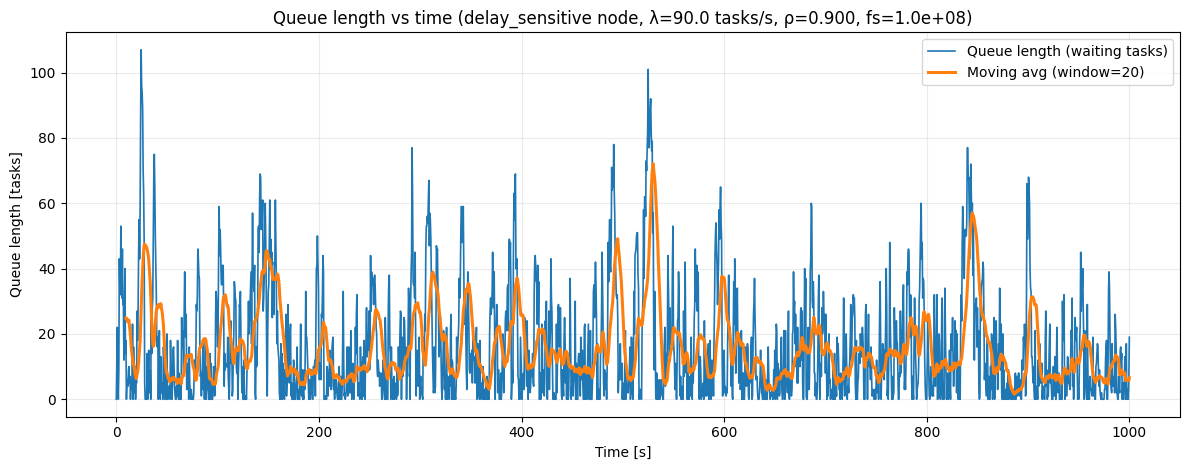

In [50]:
# --- FIFO queue "scorrimento" demo: transient -> steady-state ---
lambda_arrival = 90.0  # High arrival rate for strong congestion (ρ ≈ 0.85)
fs = 1e8               # Computational capacity
sim_time = 1000        # Longer sim to see clear transient + steady-state
sampling_interval = 0.5

# Create a DELAY_SENSITIVE node and run simulation
sim = SensingNodeSimulator(lambda_arrival=lambda_arrival, fs=fs, node_class=TaskClass.DELAY_SENSITIVE, random_seed=42)
metrics = sim.run_simulation(total_time=sim_time, sampling_interval=sampling_interval)

# Calculate utilization ρ (DELAY_SENSITIVE: mean_C = 1e6)
mean_C = 1e6
rho = lambda_arrival * mean_C / fs

print("Simulation sanity check")
print(f"  Node class: {metrics['node_class']}")
print(f"  λ = {lambda_arrival} tasks/s")
print(f"  ρ (utilization) = {rho:.3f}")
print(f"  Sim time = {sim_time}s")
print(f"  Arrivals observed = {metrics['num_arrivals']}")
print(f"  Departures observed = {metrics['num_tasks']}")
print(f"  Avg queue length (sampled) = {metrics['avg_queue_length']:.3f}")
print(f"  Avg sojourn time (completed tasks) = {metrics['avg_delay']:.4f} s")

# Plot queue length and moving average
window_size = 20
queue_lengths = np.array(metrics['queue_lengths'], dtype=float)
time_points = np.array(metrics['time_points'], dtype=float)

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(time_points, queue_lengths, linewidth=1.2, label='Queue length (waiting tasks)')

if len(queue_lengths) >= window_size:
    kernel = np.ones(window_size) / window_size
    moving_avg = np.convolve(queue_lengths, kernel, mode='valid')
    moving_avg_times = time_points[window_size-1:]
    ax.plot(moving_avg_times, moving_avg, linewidth=2.2, label=f'Moving avg (window={window_size})')

ax.set_title(f'Queue length vs time ({metrics["node_class"]} node, λ={lambda_arrival} tasks/s, ρ={rho:.3f}, fs={fs:.1e})')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Queue length [tasks]')
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


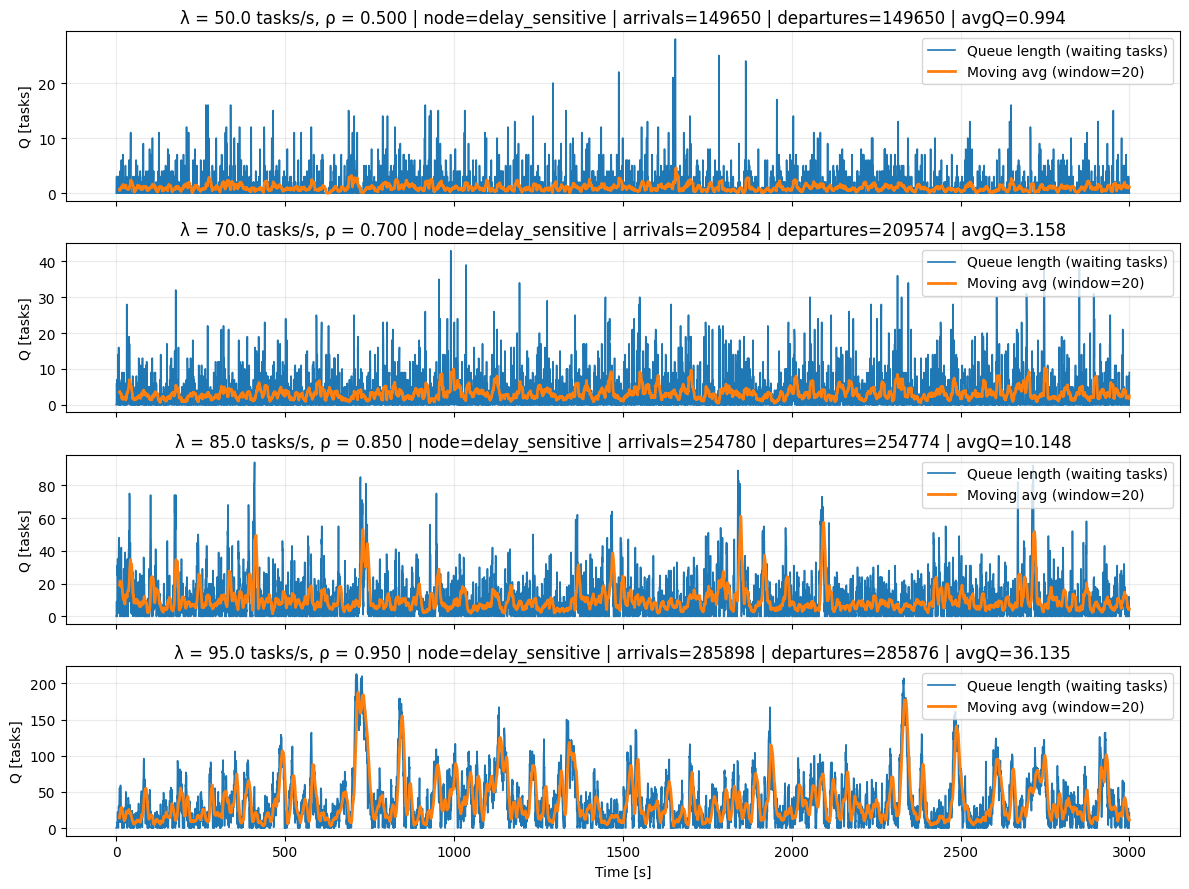


Interpretazione rapida:
- A parità di fs e node_class, aumentando λ aumenta l'utilizzazione ρ e la coda impiega più tempo a stabilizzarsi (transiente più lungo/più visibile).
- Se λ si avvicina troppo alla capacità (ρ↑1), la coda media cresce molto e le fluttuazioni diventano grandi.


In [51]:
# --- Comparison: queue length for different lambdas (same node class, same fs) ---
fs = 1e8               # Computational capacity
sim_time = 3000        # Longer sim for good transient + steady-state picture
sampling_interval = 0.5
window_size = 20
node_class = TaskClass.DELAY_SENSITIVE  # Fixed node type for comparison
mean_C_for_comp = 1e6  # DELAY_SENSITIVE parameter

lambda_list = [50.0, 70.0, 85.0, 95.0]  # Increasing ρ from ~0.5 to ~0.95 (ergodic)

fig, axes = plt.subplots(len(lambda_list), 1, figsize=(12, 9), sharex=True)
if len(lambda_list) == 1:
    axes = [axes]

for ax, lam in zip(axes, lambda_list):
    sim = SensingNodeSimulator(lambda_arrival=lam, fs=fs, node_class=node_class, random_seed=42)
    m = sim.run_simulation(total_time=sim_time, sampling_interval=sampling_interval)
    rho_lam = lam * mean_C_for_comp / fs

    t = np.array(m['time_points'], dtype=float)
    q = np.array(m['queue_lengths'], dtype=float)

    ax.plot(t, q, linewidth=1.2, label='Queue length (waiting tasks)')

    if len(q) >= window_size:
        kernel = np.ones(window_size) / window_size
        q_ma = np.convolve(q, kernel, mode='valid')
        t_ma = t[window_size - 1:]
        ax.plot(t_ma, q_ma, linewidth=2.0, label=f'Moving avg (window={window_size})')

    ax.set_title(f"λ = {lam} tasks/s, ρ = {rho_lam:.3f} | node={m['node_class']} | arrivals={m['num_arrivals']} | departures={m['num_tasks']} | avgQ={m['avg_queue_length']:.3f}")
    ax.set_ylabel('Q [tasks]')
    ax.grid(True, alpha=0.25)
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Time [s]')
plt.tight_layout()
plt.show()

print("\nInterpretazione rapida:")
print("- A parità di fs e node_class, aumentando λ aumenta l'utilizzazione ρ e la coda impiega più tempo a stabilizzarsi (transiente più lungo/più visibile).")
print("- Se λ si avvicina troppo alla capacità (ρ↑1), la coda media cresce molto e le fluttuazioni diventano grandi.")


Initial data removal for transient phase


TRANSIENT PHASE DETECTION & ELIMINATION

Simulation setup:
  λ = 85.0 tasks/s
  ρ (utilization) = 0.850
  fs = 1.0e+08
  Sim time = 3000s

Data collected: 6001 samples over 3000s

Transient detection method: variance stabilization (plateau detection)
Estimated transient end time: 1867.0 s


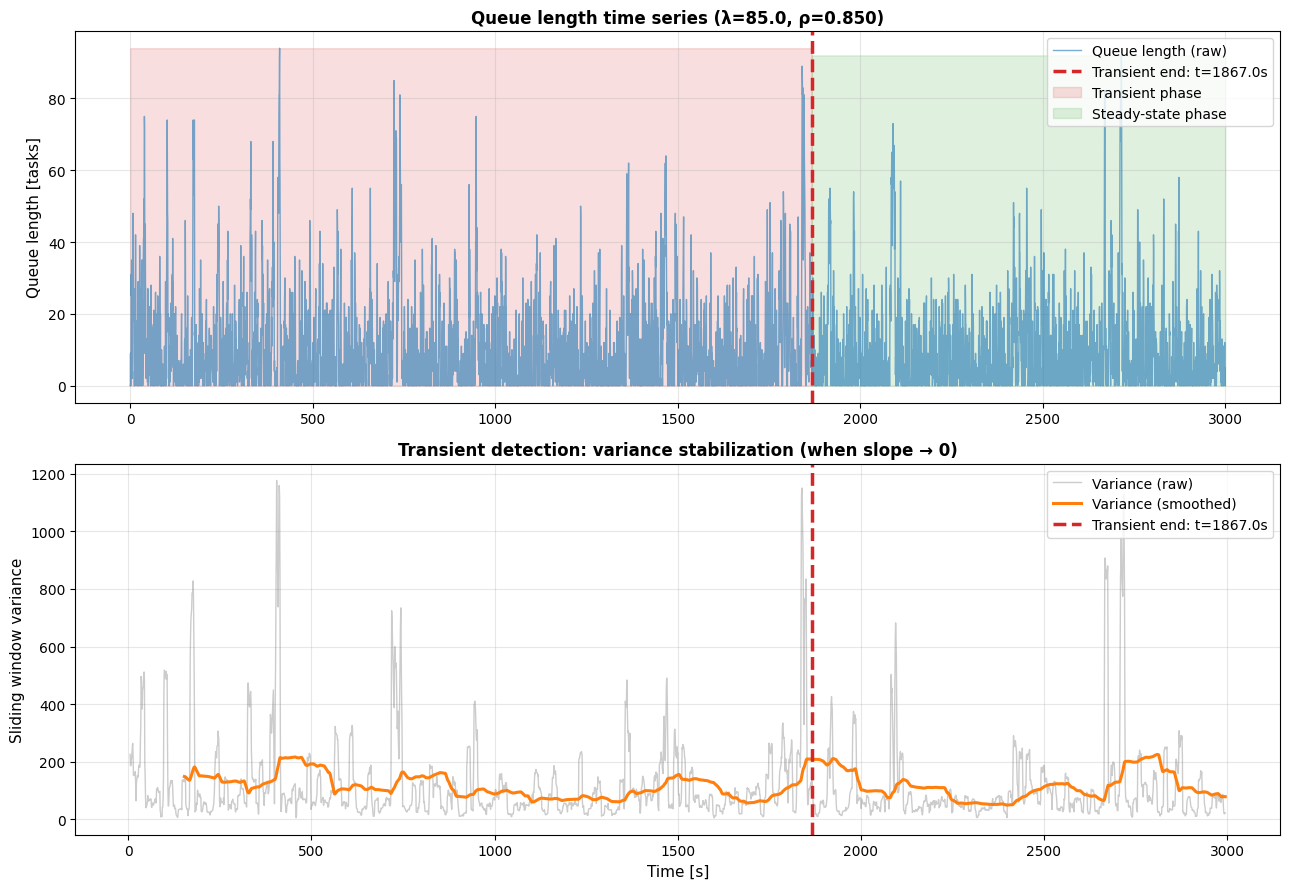


RESULTS: Transient vs Steady-State

Transient phase (0 to 1867.0s):
  Average queue length: 10.62 tasks
  Variance: 180.14

Steady-state phase (1867.0s to 3000s):
  Average queue length: 9.36 tasks
  Variance: 154.97
  Average delay: 0.1201 s (over 96310 completed tasks)

Stabilization factor:
  Q_steady / Q_transient = 0.88x
  Variance reduction: 14.0% (if positive, stabilized)


In [52]:
# --- TRANSIENT PHASE IDENTIFICATION & REMOVAL ---
# Strategy: analyze when the queue "stabilizes" by tracking:
#   1) Variance of queue length in sliding windows
#   2) Detect when variance stabilizes (low derivative)
#   3) Use stabilization point as transient end

plt.rcParams['text.usetex'] = False

fs = 1e8                        # Computational capacity
lambda_for_transient = 85.0     # High arrival rate for ergodic regime (ρ ≈ 0.85)
sim_time = 3000                 # Long simulation for clear steady-state
sampling_interval = 0.5
node_class_transient = TaskClass.DELAY_SENSITIVE  # Use DELAY_SENSITIVE for ergodic analysis

print("\n" + "="*70)
print("TRANSIENT PHASE DETECTION & ELIMINATION")
print("="*70)

sim = SensingNodeSimulator(lambda_arrival=lambda_for_transient, fs=fs, node_class=node_class_transient, random_seed=42)
metrics = sim.run_simulation(total_time=sim_time, sampling_interval=sampling_interval)

# Compute ρ for reference
mean_C = 1e6  # DELAY_SENSITIVE
rho = lambda_for_transient * mean_C / fs

print(f"\nSimulation setup:")
print(f"  λ = {lambda_for_transient} tasks/s")
print(f"  ρ (utilization) = {rho:.3f}")
print(f"  fs = {fs:.1e}")
print(f"  Sim time = {sim_time}s")

# Queue length time series
queue_lengths = np.array(metrics['queue_lengths'], dtype=float)
time_points = np.array(metrics['time_points'], dtype=float)
n_samples = len(queue_lengths)

print(f"\nData collected: {n_samples} samples over {sim_time}s")

# --- Method: Sliding window variance to detect stabilization ---
window_for_var = int(10 / sampling_interval)  # 10-second windows
step = int(1 / sampling_interval)              # 1-second steps

if window_for_var < 10:
    window_for_var = 10
if step < 1:
    step = 1

var_windows = []
time_windows = []

for i in range(0, n_samples - window_for_var, step):
    segment = queue_lengths[i:i+window_for_var]
    var_windows.append(np.var(segment))
    time_windows.append(time_points[i + window_for_var//2])

var_windows = np.array(var_windows)
time_windows = np.array(time_windows)

# Smooth variance to reduce noise
smooth_window = max(5, len(var_windows) // 20)
if len(var_windows) >= smooth_window:
    kernel = np.ones(smooth_window) / smooth_window
    var_smooth = np.convolve(var_windows, kernel, mode='valid')
    time_smooth = time_windows[smooth_window-1:]
else:
    var_smooth = var_windows
    time_smooth = time_windows

# Detect transient end: find when variance stabilizes (low rate of change)
# Strategy: look for minimum derivative (plateau region)
if len(var_smooth) > 3:
    dvar = np.abs(np.gradient(var_smooth))
    dvar_smooth = np.convolve(np.ones(3)/3, dvar, mode='same')
    
    # Ignore first 30% (early transient) and last 20% (noise at tail)
    search_start = max(0, int(0.15 * len(dvar_smooth)))
    search_end = int(0.75 * len(dvar_smooth))
    
    if search_end > search_start:
        dvar_search = dvar_smooth[search_start:search_end]
        # Find the point where derivative is minimal (most stable period)
        idx_min = search_start + np.argmin(dvar_search)
        transient_end_idx = max(search_start, idx_min - int(5 / sampling_interval))  # back up 5s for safety
        transient_end_time = float(time_smooth[transient_end_idx])
        detection_method = "variance stabilization (plateau detection)"
    else:
        transient_end_time = float(time_smooth[len(time_smooth)//3])  # fallback: 1/3 of run
        detection_method = "fallback (1/3 of simulation)"
else:
    transient_end_time = float(time_smooth[0]) if len(time_smooth) > 0 else 0.0
    detection_method = "no transient detected (short run)"

print(f"\nTransient detection method: {detection_method}")
print(f"Estimated transient end time: {transient_end_time:.1f} s")

# --- Plot 1: Queue length with transient marking ---
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

ax = axes[0]
ax.plot(time_points, queue_lengths, linewidth=1.0, alpha=0.6, label='Queue length (raw)', color='tab:blue')
ax.axvline(transient_end_time, color='tab:red', linestyle='--', linewidth=2.5, label=f'Transient end: t={transient_end_time:.1f}s')
ax.fill_between(time_points[time_points <= transient_end_time], 0, 
                queue_lengths[time_points <= transient_end_time].max(),
                alpha=0.15, color='tab:red', label='Transient phase')
ax.fill_between(time_points[time_points >= transient_end_time], 0,
                queue_lengths[time_points >= transient_end_time].max(),
                alpha=0.15, color='tab:green', label='Steady-state phase')
ax.set_ylabel('Queue length [tasks]', fontsize=11)
ax.set_title(f'Queue length time series (λ={lambda_for_transient}, ρ={rho:.3f})', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=10)

# --- Plot 2: Variance evolution and stabilization detection ---
ax = axes[1]
ax.plot(time_windows, var_windows, linewidth=1.0, alpha=0.4, label='Variance (raw)', color='gray')
if len(time_smooth) > 0:
    ax.plot(time_smooth, var_smooth, linewidth=2.2, label='Variance (smoothed)', color='tab:orange')
ax.axvline(transient_end_time, color='tab:red', linestyle='--', linewidth=2.5, label=f'Transient end: t={transient_end_time:.1f}s')
ax.set_xlabel('Time [s]', fontsize=11)
ax.set_ylabel('Sliding window variance', fontsize=11)
ax.set_title('Transient detection: variance stabilization (when slope → 0)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

# --- Compute metrics: transient vs steady-state ---
mask_transient = time_points <= transient_end_time
mask_steady = time_points >= transient_end_time

q_transient = queue_lengths[mask_transient]
q_steady = queue_lengths[mask_steady]

avg_q_transient = float(np.mean(q_transient)) if len(q_transient) > 0 else 0.0
avg_q_steady = float(np.mean(q_steady)) if len(q_steady) > 0 else 0.0

var_q_transient = float(np.var(q_transient)) if len(q_transient) > 0 else 0.0
var_q_steady = float(np.var(q_steady)) if len(q_steady) > 0 else 0.0

# Delay metrics
delay = np.array(metrics.get('delay_times', []), dtype=float)
arr_completed = np.array(metrics.get('completed_arrival_times', []), dtype=float)

if len(delay) > 0 and len(arr_completed) > 0:
    mask_delay_steady = arr_completed >= transient_end_time
    delay_steady = delay[mask_delay_steady]
    avg_delay_steady = float(np.mean(delay_steady)) if len(delay_steady) > 0 else float('nan')
    num_tasks_steady = int(np.sum(mask_delay_steady))
else:
    avg_delay_steady = float('nan')
    num_tasks_steady = 0

print(f"\n{'='*70}")
print("RESULTS: Transient vs Steady-State")
print(f"{'='*70}")
print(f"\nTransient phase (0 to {transient_end_time:.1f}s):")
print(f"  Average queue length: {avg_q_transient:.2f} tasks")
print(f"  Variance: {var_q_transient:.2f}")
print(f"\nSteady-state phase ({transient_end_time:.1f}s to {sim_time}s):")
print(f"  Average queue length: {avg_q_steady:.2f} tasks")
print(f"  Variance: {var_q_steady:.2f}")
print(f"  Average delay: {avg_delay_steady:.4f} s (over {num_tasks_steady} completed tasks)")
print(f"\nStabilization factor:")
if avg_q_transient > 0:
    print(f"  Q_steady / Q_transient = {avg_q_steady / avg_q_transient:.2f}x")
print(f"  Variance reduction: {(1 - var_q_steady/var_q_transient)*100:.1f}% (if positive, stabilized)" if var_q_transient > 0 else "  Variance: N/A")
